<font size = "6">

**Title**: F1 Dataset Analysis

<font size = "4">

**Student Name**: Ashley Lin (2781599), Natalie Chou (2742667), Victoria Jen (2742263)

<font size = "5">

Introduction:

<font size = "4">

Formula 1 (F1) is an international automobile racing series, in which teams and drivers compete on open-wheel single seater cars in competitions, aiming to achieve two major titles: the Constructor’s Championships and Driver’s Championships. Through datasets containing the information of F1 drivers, race events, performance outcomes, qualifying sessions, and championship standings over time, we aim to explore the two essential questions: Which countries produce the best drivers, and what characteristics are related to the success of the drivers? These questions are relevant in analyzing the relationships between drivers’ background and performance outcomes and main factors contributing to top results. These insights can help inform F1 teams, allowing them to craft effective future training strategies to optimize overall performance results in a highly competitive environment. 


The project begins with cleaning of the drivers, races, results, qualifying, and driver_standing datasets, by handling missing values, creating a structured format, and removing irrelevant columns. Then, these organized datasets are merged with shared identifiers, such as driverID, constructorID, and raceID, that transforms the original data into comprehensive datasets that connect the key variables of driver information, teams, and race results together  Finally, the graphs driver vs race points, top 30 constructors by average race points, and average points by nationality, total race vs average points for F1 drivers, average starting grid position vs average points by driver was created to examine the key questions for this projects. Overall, the results demonstrate that starting grid position and constructor/team performance are the most important factors related to driver success, while age, nationality, and experience show weaker or less direct patterns.

<font size = "5">

Data Description: 

<font size = "4">

In this project, we used four Formula 1 datasets, which are drivers.csv, results.csv, constructors.csv, and races.csv. The number of observations in each dataset was calculated using the len() function. The drivers dataset contains 854 observations, where each row represents one driver and includes information such as name, nationality, and date of birth. The results dataset contains 25,660 observations, where each row represents one driver’s performance in one specific race, including raceId, driverId, constructorId, grid position, finishing order, and points earned. The constructors dataset contains 211 observations, where each row represents one racing team and includes information such as constructor name and nationality. The race's dataset contains 1,079 observations, where each row represents one Formula 1 race and includes information such as year, round, race name, and date. These datasets were selected in order to connect driver background, team information, race details, and performance results, allowing a closer analysis of which countries produce the best drivers and what characteristics are related to success.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_races = pd.read_csv("1-Formula_One/races.csv")
drivers = pd.read_csv("1-Formula_One/drivers.csv")
results = pd.read_csv("1-Formula_One/results.csv")
df_constructors = pd.read_csv("1-Formula_One/constructors.csv")

<font size = "5">

Data Cleaning

<font size = "4">

To begin the project, we applied several data cleaning procedures to multiple datasets, including races, drivers, and constructors, to make sure that the tables would be easier to understand and work with. First, missing values represented as \N were replaced with np.nan using the replace() function, so they could be correctly identified as missing data. For the races dataset, unnecessary columns, such as practice session information, were removed to keep only relevant variables such as raceId, year, round, circuitId, name, date, and time. For the drivers dataset, non-numeric values in the number column were identified using query() and str.isnumeric(), then replaced with np.nan values and converted into numeric format using pd.to_numeric(). In the results dataset, non-numeric entries in the position column were identified and replaced, and only important columns such as raceId, driverId, constructorId, grid, positionOrder, and points were kept. The driver standings dataset was simplified by selecting key columns including raceId, driverId, points, position, and wins. The constructors and qualifying datasets were also cleaned by removing unnecessary columns and keeping only variables useful for the analysis. In addition, a new age column was created by taking the birth year from the driver’s dob (date of birth) column and subtracting it from the race year. This allowed us to compare driver age with race performance, such as points earned. These cleaning procedures made the datasets more structured and ready for further analysis. 

In [2]:
#Cleaning race.csv

#Replace \N to NA
df_races = df_races.replace("\\N", np.nan)

#Turn the date into datetime
date_col = ["date", "fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
for col in date_col:
    df_races[col] = pd.to_datetime(df_races[col])

#Delete unnecessary column - the fp1, fp2, fp3, quali, and sprint data are mostly missing and therefore we decided to exclude it
df_races = df_races[["raceId", "year"]]

display(df_races)

,raceId,year
0,1,2009
1,2,2009
2,3,2009
3,4,2009
4,5,2009
...,...,...
1074,1092,2022
1075,1093,2022
1076,1094,2022
1077,1095,2022


In [3]:
drivers_nonnumeric = drivers.query("number.str.isnumeric() == False")
non_number_vals = pd.unique(drivers_nonnumeric["number"])

print(non_number_vals)

replace_vals = [np.nan]

drivers["number"] = drivers["number"].replace(non_number_vals, replace_vals)

drivers["number"] = pd.to_numeric(drivers["number"])

df_drivers = drivers[["driverId", "forename", "surname", "nationality", "dob"]]

display(df_drivers)

['\\N']


,driverId,forename,surname,nationality,dob
0,1,Lewis,Hamilton,British,1985-01-07
1,2,Nick,Heidfeld,German,1977-05-10
2,3,Nico,Rosberg,German,1985-06-27
3,4,Fernando,Alonso,Spanish,1981-07-29
4,5,Heikki,Kovalainen,Finnish,1981-10-19
...,...,...,...,...,...
849,851,Jack,Aitken,British,1995-09-23
850,852,Yuki,Tsunoda,Japanese,2000-05-11
851,853,Nikita,Mazepin,Russian,1999-03-02
852,854,Mick,Schumacher,German,1999-03-22


In [4]:
#Cleaning results.csv

#turn into numeric values
results_nonnumeric = results.query("position.str.isnumeric() == False")
non_number_vals = pd.unique(results_nonnumeric["position"])

print(non_number_vals)

replace_vals = [np.nan]

results["position"] = results["position"].replace(non_number_vals, replace_vals)

results["position"] = pd.to_numeric(results["position"])

#remove unnecessary columns
df_results = results[["resultId", "raceId", "driverId", "constructorId", "grid", "points"]]

display(df_results)

['\\N']


,resultId,raceId,driverId,constructorId,grid,points
0,1,18,1,1,1,10.0
1,2,18,2,2,5,8.0
2,3,18,3,3,7,6.0
3,4,18,4,4,11,5.0
4,5,18,5,1,3,4.0
...,...,...,...,...,...,...
25655,25661,1086,825,210,13,0.0
25656,25662,1086,848,3,17,0.0
25657,25663,1086,849,3,19,0.0
25658,25664,1086,852,213,16,0.0


In [5]:
#Cleaning constructors.csv

df_constructors = pd.read_csv("1-Formula_One/constructors.csv")

df_constructors = df_constructors[["constructorId", "constructorRef"]]

display(df_constructors)

,constructorId,constructorRef
0,1,mclaren
1,2,bmw_sauber
2,3,williams
3,4,renault
4,5,toro_rosso
...,...,...
206,209,manor
207,210,haas
208,211,racing_point
209,213,alphatauri


<font size = "5">

Merging Procedure

<font size = "3">
To create a more comprehensive dataset, we aimed to combine driver information, race results, constructors, and race information. We began by creating a new dataset named df_merged_drivers_result that merged the results and drivers dataset with their shared identifier, driverID, and added driver characteristics into the race results. Next, to match the teams with driver information and race results,  df_merged_drivers_result was merged with the constructors dataset through the constructorID, creating a new dataset named df_merged_constructor_results. Finally, df_merged_constructor_results was merged with the races dataset to incorporate specific race information to create df_merged, which contained only relevant columns, such as resultsId, raceId, driverId, constructorId, grid, positionOrder, points, forename, surname, nationality, dob, constructorRef, and year, that is necessary to address the key questions, 

In [6]:
#merging results.csv and drivers.csv
df_merged_drivers_results = pd.merge(left = df_results, right = df_drivers, how = "left", on = "driverId")

#merging with constructor.csv
df_merged_constructor_results = pd.merge(left = df_merged_drivers_results, right = df_constructors, how = "left", on = "constructorId")

#merging with races.csv
df_merged = pd.merge(left = df_merged_constructor_results, right = df_races, how = "left", on = "raceId")

display(df_merged)

,resultId,raceId,driverId,constructorId,grid,points,forename,surname,nationality,dob,constructorRef,year
0,1,18,1,1,1,10.0,Lewis,Hamilton,British,1985-01-07,mclaren,2008
1,2,18,2,2,5,8.0,Nick,Heidfeld,German,1977-05-10,bmw_sauber,2008
2,3,18,3,3,7,6.0,Nico,Rosberg,German,1985-06-27,williams,2008
3,4,18,4,4,11,5.0,Fernando,Alonso,Spanish,1981-07-29,renault,2008
4,5,18,5,1,3,4.0,Heikki,Kovalainen,Finnish,1981-10-19,mclaren,2008
...,...,...,...,...,...,...,...,...,...,...,...,...
25655,25661,1086,825,210,13,0.0,Kevin,Magnussen,Danish,1992-10-05,haas,2022
25656,25662,1086,848,3,17,0.0,Alexander,Albon,Thai,1996-03-23,williams,2022
25657,25663,1086,849,3,19,0.0,Nicholas,Latifi,Canadian,1995-06-29,williams,2022
25658,25664,1086,852,213,16,0.0,Yuki,Tsunoda,Japanese,2000-05-11,alphatauri,2022


In [7]:
#Adding "age" column based on the race year and driver date of birth
df_merged["dob_year"] = df_merged["dob"].str[0:4]
df_merged["dob_year"] = pd.to_numeric(df_merged["dob_year"])
df_merged["age"] = df_merged["year"] - df_merged["dob_year"]
display(df_merged[["dob", "dob_year", "year", "age"]])

,dob,dob_year,year,age
0,1985-01-07,1985,2008,23
1,1977-05-10,1977,2008,31
2,1985-06-27,1985,2008,23
3,1981-07-29,1981,2008,27
4,1981-10-19,1981,2008,27
...,...,...,...,...
25655,1992-10-05,1992,2022,30
25656,1996-03-23,1996,2022,26
25657,1995-06-29,1995,2022,27
25658,2000-05-11,2000,2022,22


<font size = "5">

Main Column: Descriptive Statistics

In [8]:
stats = df_merged[["grid", "points", "age"]].describe().round(2)

print(stats)

           grid    points       age
count  25660.00  25660.00  25660.00
mean      11.19      1.85     29.96
std        7.25      4.13      5.28
min        0.00      0.00     18.00
25%        5.00      0.00     26.00
50%       11.00      0.00     29.00
75%       17.00      2.00     33.00
max       34.00     50.00     59.00


<font size = "5">

Results

<font size = "4">

1. Driver's age vs. Driver's average point

<font size = "3">
The graph is right skewed and have it's middle range is around 20-30. This means that the drivers earned more points when they're age is around 20 to 30 years old, which creates a slightly sharp increase. Then, the race points becomes lower when the drivers are aging. 


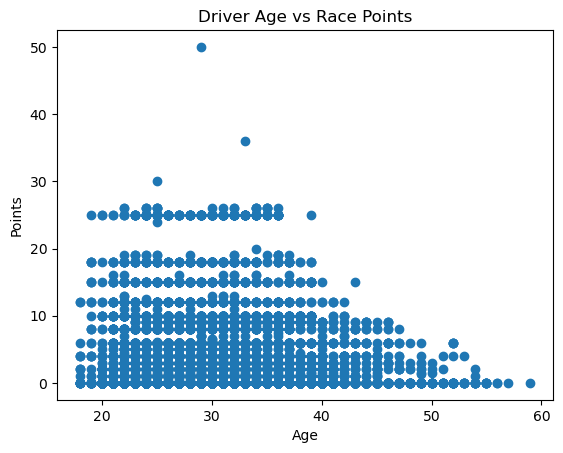

In [9]:
plt.scatter(df_merged["age"], df_merged["points"])

plt.xlabel("Age")
plt.ylabel("Points")
plt.title("Driver Age vs Race Points")

plt.show()

<font size = "4">

2. Driver's Total Race vs Driver's Average Points

<font size = "3">

We assumed that the drivers that are more experienced will have more average points. Therefore, we created a scatterplot that presents the linear relationship between the total races that each driver has and their average points. Due to this graph, we can see that there is a positive linear relationship between the total number of races and average point that driver earned.

,total_races,avg_points,total_points
driverId,,,
1,301,14.31,4308.5
830,154,11.64,1792.5
20,291,10.57,3077.0
822,192,9.24,1775.0
3,206,7.74,1594.5
...,...,...,...
148,22,0.00,0.0
452,1,0.00,0.0
451,1,0.00,0.0


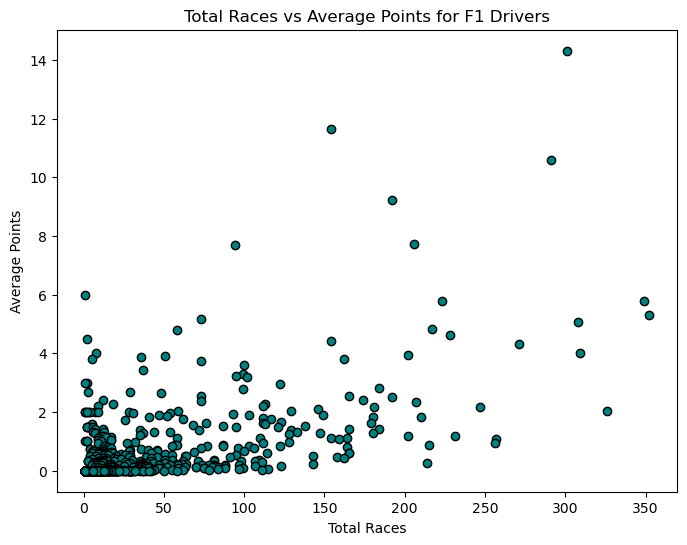

In [10]:
driver_summary = (
    df_merged.groupby("driverId")
    .agg(
        total_races=("raceId", "count"),
        avg_points=("points", "mean"),
        total_points=("points", "sum")
    )
    .sort_values(by="avg_points", ascending=False)
    .round(2)
)

display(driver_summary)

plt.figure(figsize=(8, 6))

plt.scatter(
    x=driver_summary["total_races"],
    y=driver_summary["avg_points"],
    color="teal",
    edgecolor="black"
)

plt.xlabel("Total Races")
plt.ylabel("Average Points")
plt.title("Total Races vs Average Points for F1 Drivers")

plt.show()

<font size = "4">

3. Driver's Average starting grid position vs Driver's Average Points

<font size = "3">

We assumed that drivers who started closer to the front will earn more average points. This scatterplot shows a negative relationship between average starting grid position and average points, which supports our hypothesis. Since lower grid numbers mean better starting positions, drivers who started closer to the front would score more points on average.

,avg_grid,avg_points,total_races
driverId,,,
1,3.84,14.31,301
2,11.34,1.41,184
3,6.90,7.74,206
4,8.66,5.79,349
5,13.74,0.94,112
...,...,...,...
851,17.00,0.00,1
852,12.20,1.23,35
853,18.50,0.00,22


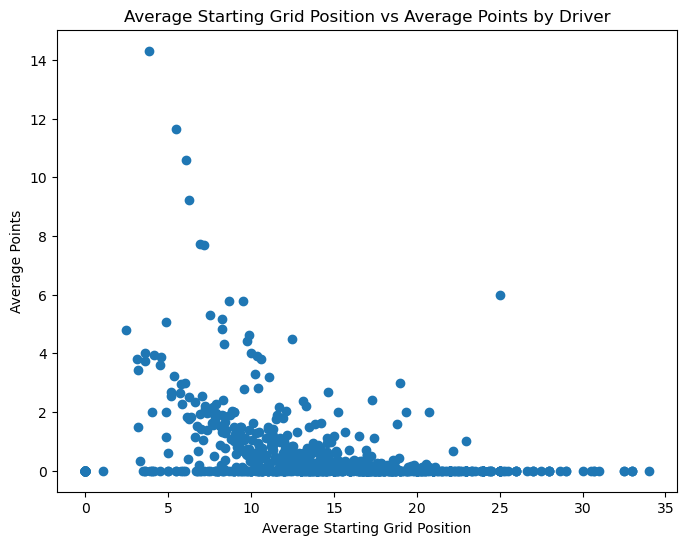

In [11]:
driver_grid_points = (
    df_merged.groupby("driverId")
    .agg(
        avg_grid=("grid", "mean"),
        avg_points=("points", "mean"),
        total_races=("raceId", "count")
    ).round(2)
)

display(driver_grid_points)

plt.figure(figsize=(8, 6))

plt.scatter(
    driver_grid_points["avg_grid"],
    driver_grid_points["avg_points"]
)

plt.xlabel("Average Starting Grid Position")
plt.ylabel("Average Points")
plt.title("Average Starting Grid Position vs Average Points by Driver")

plt.show()

<font size = "4">

4. Top 30 Constructors by Average Race Points

<font size = "3">

The graph show a strong right-skewed distribution. The majority of teams achieve a low average points per race while a only a small number of teams remained at the top. Constructors such as Mercedes, Red Bull, and Brawn attained the best performance results, averaging approximately 12, 9, and 5 points per race, respectively. Following the top performing teams, however, the graph revels a steep decline of results from the majority of the team, averaging around 1 to 3 points per race. These results indicates that Formula 1 racing performance is dominated by elite teams, while the majority of constructors perform at lower levels of performance. This effectively forms a large number of competitors who cannot consistently compete with high-performing teams in Formula 1 racing 


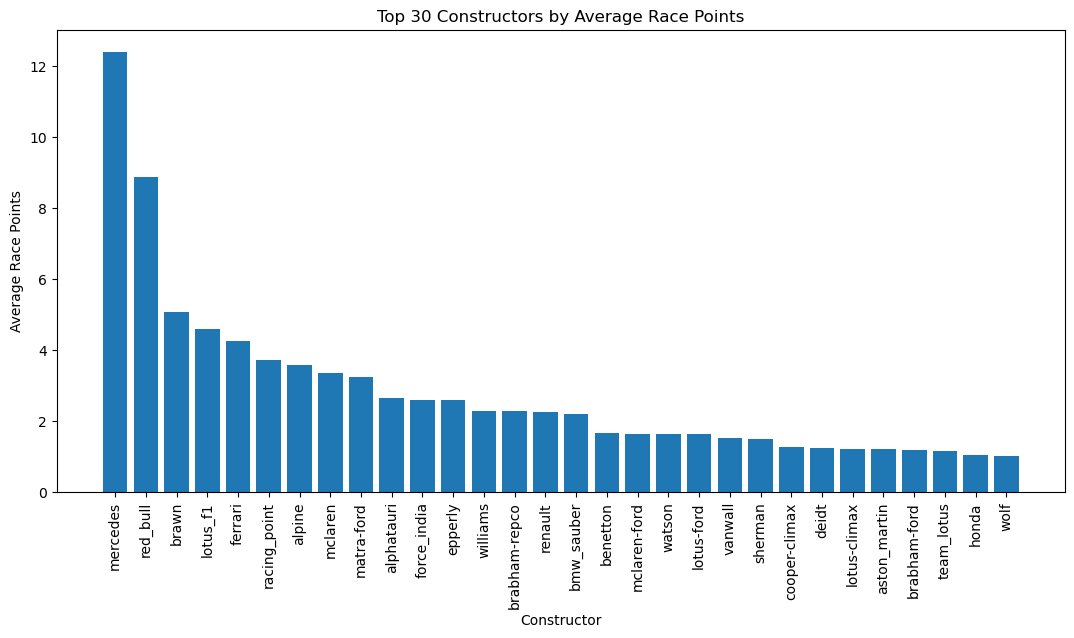

In [12]:
constructors = pd.unique(df_merged["constructorRef"])

constructor_list = []
avg_points_list = []

for constructor in constructors:
    df_constructor = df_merged.query("constructorRef ==   @constructor")
    
    total_points = df_constructor["points"].sum()
    num_rows =  len(df_constructor)
    avg_points = total_points / num_rows
    
    constructor_list.append(constructor)
    avg_points_list.append(avg_points)


top_constructor_list = []
top_avg_points_list = []

for num in range(30):
    max_points = max(avg_points_list)

    max_index =  avg_points_list.index(max_points)
    
    top_constructor_list.append(constructor_list[max_index])
    top_avg_points_list.append(avg_points_list[max_index])
    
    constructor_list.pop(max_index)
    avg_points_list.pop(max_index)


plt.figure(figsize=(13, 6))

plt.bar(top_constructor_list, top_avg_points_list)

plt.xlabel("Constructor")
plt.ylabel("Average Race Points")
plt.title("Top 30 Constructors by Average Race Points")

plt.xticks(rotation=90) 

plt.show()

<font size = "4">

5. Driver's Average Points by Nationality

<font size = "3">

The graph show a strong right-skewed distribution. We added up the total points of each nation and divided it by the number of drivers to calculate the average points per nationality. Looking at the graph, the Monegasque drivers, who are from Monaco, are the drivers that received the most average points. Therefore, Monaco is the country that gives the best driver. 


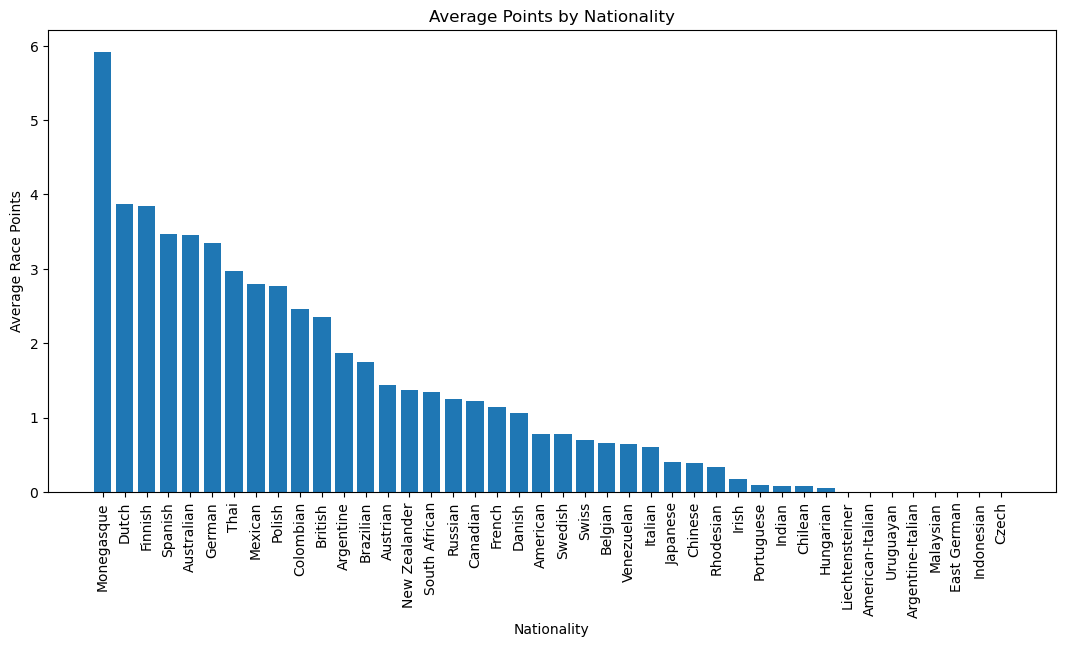

In [14]:
nationalities = pd.unique(df_merged["nationality"])


nationality_list = []
avg_points_list = []

for nationality in nationalities:
    df_nationality = df_merged.query("nationality == @nationality")
    
    total_points = df_nationality["points"].sum()
    num_drivers = len(df_nationality)
    avg_points = total_points / num_drivers
    
    nationality_list.append(nationality)
    avg_points_list.append(avg_points)

df_nationality_points = pd.DataFrame()

df_nationality_points["nationality"] = nationality_list
df_nationality_points["avg_points"] = avg_points_list

df_nationality_points = df_nationality_points.sort_values("avg_points", ascending=False)

plt.figure(figsize=(13, 6))

plt.bar(df_nationality_points["nationality"], df_nationality_points["avg_points"])

plt.xlabel("Nationality")
plt.ylabel("Average Race Points")
plt.title("Average Points by Nationality")

plt.xticks(rotation=90)

plt.show()

<font size = "5">

Discussion/Main Finding